# Multi-Class Classification — NHS Knee Replacement Outcomes

This notebook extends the binary classification in `modelling_experiment.ipynb` to a **3-class** problem using the same preprocessed features.

## Target Classes
| Class | Label | Definition |
|-------|-------|------------|
| 0 | **Worsening** | OKS delta < 0 |
| 1 | **No Meaningful Improvement** | 0 ≤ OKS delta < 7 |
| 2 | **Meaningful Improvement** | OKS delta ≥ 7 |

## Approach
- Features: re-use the fully preprocessed & encoded X from `feature_engineering.ipynb` (MICE-imputed, OHE, feature-engineered)
- Target: reconstruct 3-class y by replaying the same train-test split on the original data
- Models: Logistic Regression (OvR), LR Balanced, LR SMOTE, Random Forest
- Evaluation: macro + weighted metrics, per-class breakdown, 3×3 confusion matrices

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_auc_score
)
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
print('Libraries loaded')

Libraries loaded


## 1. Load Data
We load the already-encoded feature files from `feature_engineering.ipynb` and reconstruct the 3-class target by replaying the exact same train-test split on the original data.

In [6]:
# ============================================================================
# LOAD ENCODED FEATURES (already MICE-imputed + one-hot encoded)
# ============================================================================
X_train = pd.read_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet')
X_test  = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

# ============================================================================
# RECONSTRUCT 3-CLASS TARGET
# We replay the exact same train_test_split (random_state=42, stratify=binary y)
# to get the oks_delta values in the same row order as the saved X files.
# ============================================================================
df_orig = pd.read_parquet('../data/cleaned/knee-provider-target.parquet')

# Binary target used in original split (NaN oks_delta -> 1 via np.where)
y_binary_all = df_orig['oks_target_variable']

# Replay split to get oks_delta aligned to X_train / X_test row order
df_train_orig, df_test_orig = train_test_split(
    df_orig, test_size=0.2, random_state=42, stratify=y_binary_all
)

oks_delta_train = df_train_orig['oks_delta'].reset_index(drop=True)
oks_delta_test  = df_test_orig['oks_delta'].reset_index(drop=True)

# Create 3-class y
bins   = [-np.inf, 0, 7, np.inf]
labels = [0, 1, 2]

y_train_raw = pd.cut(oks_delta_train, bins=bins, labels=labels).astype('Int64')
y_test_raw  = pd.cut(oks_delta_test,  bins=bins, labels=labels).astype('Int64')

# Drop rows where oks_delta was NaN (cannot assign class)
train_valid = y_train_raw.notna()
test_valid  = y_test_raw.notna()

X_train_mc = X_train[train_valid].reset_index(drop=True)
X_test_mc  = X_test[test_valid].reset_index(drop=True)
y_train_mc = y_train_raw[train_valid].reset_index(drop=True).astype(int)
y_test_mc  = y_test_raw[test_valid].reset_index(drop=True).astype(int)

print(f'\nAfter dropping NaN oks_delta rows:')
print(f'  X_train_mc: {X_train_mc.shape} | X_test_mc: {X_test_mc.shape}')
print(f'  Dropped from train: {train_valid.sum() - len(X_train_mc):,} | Dropped from test: {test_valid.sum() - len(X_test_mc):,}')

X_train shape: (105905, 57)
X_test shape:  (26477, 57)

After dropping NaN oks_delta rows:
  X_train_mc: (103974, 57) | X_test_mc: (26009, 57)
  Dropped from train: 0 | Dropped from test: 0



Train set (103,974 rows):
  Class 0 (Worsening (delta < 0)):  5,574 (5.4%)
  Class 1 (No Meaningful Improvement (0-7)): 11,592 (11.1%)
  Class 2 (Meaningful Improvement (delta >= 7)): 86,808 (83.5%)

Test set (26,009 rows):
  Class 0 (Worsening (delta < 0)):  1,439 (5.5%)
  Class 1 (No Meaningful Improvement (0-7)):  2,868 (11.0%)
  Class 2 (Meaningful Improvement (delta >= 7)): 21,702 (83.4%)


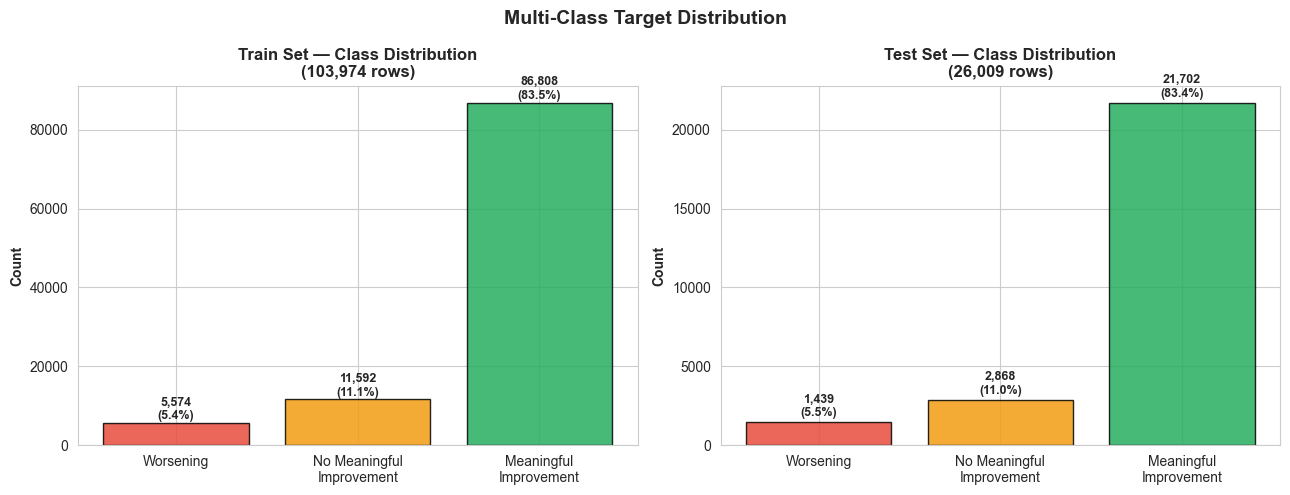

In [7]:
# ============================================================================
# CLASS DISTRIBUTION
# ============================================================================
CLASS_NAMES = {0: 'Worsening\n(delta < 0)', 1: 'No Meaningful\nImprovement\n(0-7)', 2: 'Meaningful\nImprovement\n(delta >= 7)'}
CLASS_LABELS = ['Worsening', 'No Meaningful\nImprovement', 'Meaningful\nImprovement']

for split_name, y in [('Train', y_train_mc), ('Test', y_test_mc)]:
    counts = y.value_counts().sort_index()
    pcts   = y.value_counts(normalize=True).sort_index() * 100
    print(f'\n{split_name} set ({len(y):,} rows):')
    for cls in [0, 1, 2]:
        print(f'  Class {cls} ({CLASS_NAMES[cls].replace(chr(10), " ")}): {counts[cls]:>6,} ({pcts[cls]:.1f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#e74c3c', '#f39c12', '#27ae60']

for ax, (split_name, y) in zip(axes, [('Train', y_train_mc), ('Test', y_test_mc)]):
    counts = y.value_counts().sort_index()
    bars = ax.bar(range(3), counts.values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_xticks(range(3))
    ax.set_xticklabels(CLASS_LABELS, fontsize=10)
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title(f'{split_name} Set — Class Distribution\n({len(y):,} rows)', fontweight='bold')
    for bar, count in zip(bars, counts.values):
        pct = count / len(y) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Multi-Class Target Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Logistic Regression — Multi-Class
Four configurations using One-vs-Rest (OvR):
- No weights
- Balanced class weights  
- SMOTE oversampling
- LASSO (L1)

Evaluated via 5-fold stratified cross-validation.

In [8]:
# ============================================================================
# LOGISTIC REGRESSION — MULTI-CLASS (5-Fold CV)
# ============================================================================
from sklearn.metrics import classification_report

lr_models = {
    'LR - No weights': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs',
        multi_class='ovr', n_jobs=-1
    ),
    'LR - Balanced weights': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs',
        multi_class='ovr', class_weight='balanced', n_jobs=-1
    ),
    'LR - SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs',
                                  multi_class='ovr', n_jobs=-1))
    ]),
    'LR - LASSO (L1)': LogisticRegression(
        max_iter=2000, random_state=42, solver='saga',
        penalty='l1', multi_class='ovr', n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_val_preds  = {}  # CV predictions
lr_val_probas = {}  # CV probabilities
lr_cv_results = {}

print('=' * 80)
print('LOGISTIC REGRESSION — CROSS-VALIDATION RESULTS')
print('=' * 80)

for name, model in lr_models.items():
    print(f'\n--- {name} ---')
    
    # CV predictions
    y_pred_cv  = cross_val_predict(clone(model), X_train_mc, y_train_mc, cv=cv, method='predict')
    y_proba_cv = cross_val_predict(clone(model), X_train_mc, y_train_mc, cv=cv, method='predict_proba')
    
    lr_val_preds[name]  = y_pred_cv
    lr_val_probas[name] = y_proba_cv
    
    mac_p = precision_score(y_train_mc, y_pred_cv, average='macro', zero_division=0)
    mac_r = recall_score(y_train_mc, y_pred_cv, average='macro', zero_division=0)
    mac_f = f1_score(y_train_mc, y_pred_cv, average='macro', zero_division=0)
    wt_f  = f1_score(y_train_mc, y_pred_cv, average='weighted', zero_division=0)
    
    lr_cv_results[name] = {
        'macro_precision': mac_p, 'macro_recall': mac_r,
        'macro_f1': mac_f, 'weighted_f1': wt_f
    }
    print(f'  Macro  P={mac_p:.4f}  R={mac_r:.4f}  F1={mac_f:.4f}')
    print(f'  Weighted F1={wt_f:.4f}')
    print(classification_report(y_train_mc, y_pred_cv,
                                 target_names=['Worsening', 'No Improv.', 'Improvement'],
                                 zero_division=0))

# Summary table
print('\n' + '=' * 70)
print('LR CROSS-VALIDATION SUMMARY')
print('=' * 70)
summary_lr = pd.DataFrame(lr_cv_results).T.round(4)
print(summary_lr.to_string())

LOGISTIC REGRESSION — CROSS-VALIDATION RESULTS

--- LR - No weights ---
  Macro  P=0.5651  R=0.3428  F1=0.3231
  Weighted F1=0.7676
              precision    recall  f1-score   support

   Worsening       0.42      0.00      0.00      5574
  No Improv.       0.43      0.03      0.05     11592
 Improvement       0.84      1.00      0.91     86808

    accuracy                           0.84    103974
   macro avg       0.57      0.34      0.32    103974
weighted avg       0.77      0.84      0.77    103974


--- LR - Balanced weights ---
  Macro  P=0.3916  R=0.4485  F1=0.3826
  Weighted F1=0.6756
              precision    recall  f1-score   support

   Worsening       0.11      0.41      0.18      5574
  No Improv.       0.16      0.26      0.20     11592
 Improvement       0.90      0.67      0.77     86808

    accuracy                           0.61    103974
   macro avg       0.39      0.45      0.38    103974
weighted avg       0.78      0.61      0.68    103974


--- LR - SMOTE

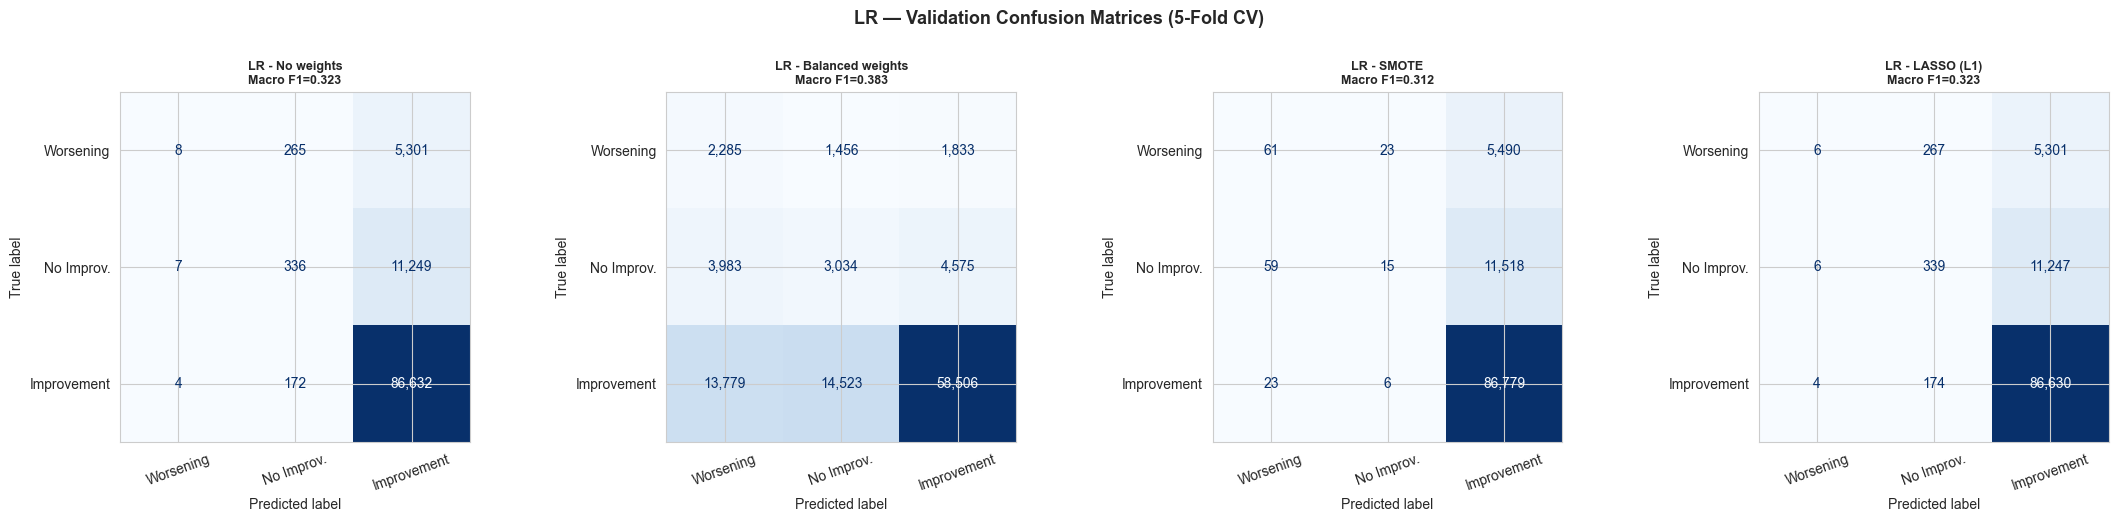

In [9]:
# ============================================================================
# LR CONFUSION MATRICES (Cross-Validation)
# ============================================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, y_pred) in zip(axes, lr_val_preds.items()):
    cm = confusion_matrix(y_train_mc, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Worsening', 'No Improv.', 'Improvement']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')
    mac_f = f1_score(y_train_mc, y_pred, average='macro', zero_division=0)
    ax.set_title(f'{name}\nMacro F1={mac_f:.3f}', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=20)

fig.suptitle('LR — Validation Confusion Matrices (5-Fold CV)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================================
# THRESHOLD EXPERIMENTS — LR No Weights
# Sweep t0 (Worsening) and t1 (No Improvement) independently.
# Decision rule: predict the class with highest P >= its threshold.
#                If no class qualifies, default to class 2 (Improvement).
# ============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Custom threshold prediction ---
def predict_with_thresholds(probas, t0, t1, t2=0.0):
    thresholds = np.array([t0, t1, t2])
    masked = np.where(probas >= thresholds, probas, -1.0)
    has_candidate = (masked >= 0).any(axis=1)
    return np.where(has_candidate, masked.argmax(axis=1), 2)

# Validation probabilities for LR - No weights
lr_probas = lr_val_probas['LR - No weights']
y_true    = y_train_mc.values

# --- Sweep ---
thresholds = [0.10, 0.20, 0.30, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80, 0.90]

rows = []
for t0 in thresholds:
    for t1 in thresholds:
        y_pred = predict_with_thresholds(lr_probas, t0, t1)
        rows.append({
            't0 (Worsening)': t0,
            't1 (No Improv)': t1,
            'Prec(0)':  round(precision_score(y_true, y_pred, labels=[0], average='macro', zero_division=0), 3),
            'Rec(0)':   round(recall_score(y_true, y_pred,    labels=[0], average='macro', zero_division=0), 3),
            'n_pred(0)': int((y_pred == 0).sum()),
            'Prec(1)':  round(precision_score(y_true, y_pred, labels=[1], average='macro', zero_division=0), 3),
            'Rec(1)':   round(recall_score(y_true, y_pred,    labels=[1], average='macro', zero_division=0), 3),
            'n_pred(1)': int((y_pred == 1).sum()),
            'MacroF1':  round(f1_score(y_true, y_pred, average='macro', zero_division=0), 3),
        })

sweep = pd.DataFrame(rows)
print('LR - No weights | Validation | Threshold Sweep')
print('(n_pred = how many patients flagged as that class out of', len(y_true), 'total)')
print()
print(sweep.to_string(index=False))
sweep

LR - No weights | Validation | Threshold Sweep
(n_pred = how many patients flagged as that class out of 103974 total)

 t0 (Worsening)  t1 (No Improv)  Prec(0)  Rec(0)  n_pred(0)  Prec(1)  Rec(1)  n_pred(1)  MacroF1
           0.10            0.10    0.421   0.001         19    0.435   0.029        773    0.323
           0.10            0.20    0.421   0.001         19    0.435   0.029        773    0.323
           0.10            0.30    0.421   0.001         19    0.435   0.029        773    0.323
           0.10            0.40    0.382   0.005         76    0.471   0.019        467    0.319
           0.10            0.45    0.375   0.020        299    0.400   0.003         95    0.319
           0.10            0.50    0.396   0.028        391    0.000   0.000          2    0.321
           0.10            0.60    0.399   0.028        393    0.000   0.000          0    0.321
           0.10            0.70    0.399   0.028        393    0.000   0.000          0    0.321
        

,t0 (Worsening),t1 (No Improv),Prec(0),Rec(0),n_pred(0),Prec(1),Rec(1),n_pred(1),MacroF1
0,0.1,0.10,0.421,0.001,19,0.435,0.029,773,0.323
1,0.1,0.20,0.421,0.001,19,0.435,0.029,773,0.323
2,0.1,0.30,0.421,0.001,19,0.435,0.029,773,0.323
3,0.1,0.40,0.382,0.005,76,0.471,0.019,467,0.319
4,0.1,0.45,0.375,0.020,299,0.400,0.003,95,0.319
...,...,...,...,...,...,...,...,...,...
95,0.9,0.50,0.000,0.000,0,0.000,0.000,2,0.303
96,0.9,0.60,0.000,0.000,0,0.000,0.000,0,0.303
97,0.9,0.70,0.000,0.000,0,0.000,0.000,0,0.303
98,0.9,0.80,0.000,0.000,0,0.000,0.000,0,0.303


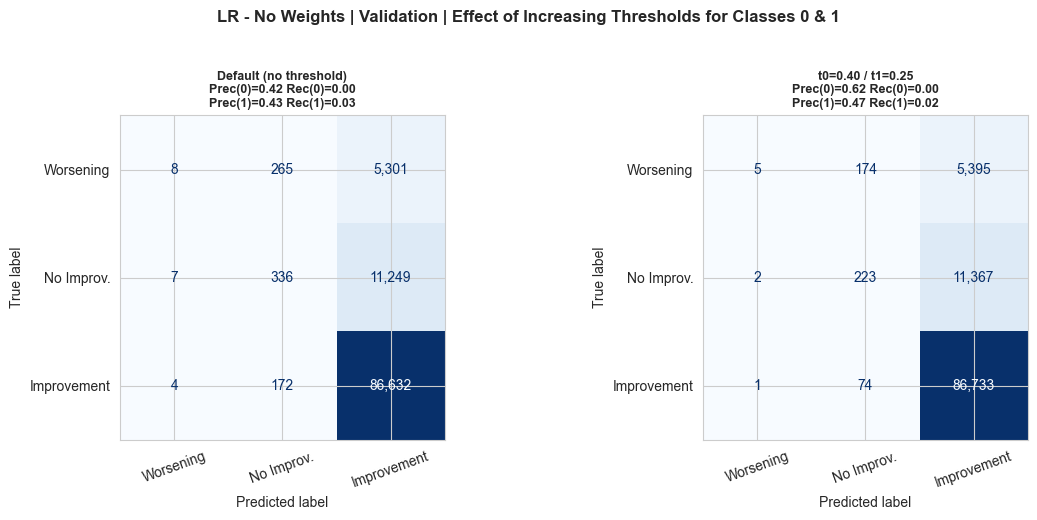

In [19]:
# ============================================================================
# CONFUSION MATRICES — LR No Weights at specific threshold combinations
# Edit the list below after reviewing the sweep table above
# ============================================================================

threshold_combos = [
    (0.0,  0.0,  'Default (no threshold)'),
    (0.45, 0.40, 't0=0.40 / t1=0.25'),
]

fig, axes = plt.subplots(1, len(threshold_combos), figsize=(6 * len(threshold_combos), 5))

for ax, (t0, t1, label) in zip(axes, threshold_combos):
    y_pred = predict_with_thresholds(lr_probas, t0, t1)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Worsening', 'No Improv.', 'Improvement'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')
    p0 = precision_score(y_true, y_pred, labels=[0], average='macro', zero_division=0)
    r0 = recall_score(y_true, y_pred, labels=[0], average='macro', zero_division=0)
    p1 = precision_score(y_true, y_pred, labels=[1], average='macro', zero_division=0)
    r1 = recall_score(y_true, y_pred, labels=[1], average='macro', zero_division=0)
    ax.set_title(f'{label}\nPrec(0)={p0:.2f} Rec(0)={r0:.2f}\nPrec(1)={p1:.2f} Rec(1)={r1:.2f}',
                 fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=20)

fig.suptitle('LR - No Weights | Validation | Effect of Increasing Thresholds for Classes 0 & 1',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 3. Random Forest — Multi-Class
Hyperparameter tuning via GridSearchCV, evaluated with 5-fold stratified CV. Random Forest handles multi-class natively.

In [10]:
# ============================================================================
# RANDOM FOREST — HYPERPARAMETER TUNING + MULTI-CLASS CV
# ============================================================================
print('=' * 80)
print('RANDOM FOREST — HYPERPARAMETER TUNING (GridSearchCV)')
print('=' * 80)

param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 15, 20],
    'min_samples_split':[5, 10],
    'min_samples_leaf': [2, 4],
    'class_weight':     ['balanced', None],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_mc = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_inner,
    scoring='f1_macro',   # macro F1 for multi-class
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print('Running grid search (scoring = f1_macro)...')
grid_search_mc.fit(X_train_mc, y_train_mc)

print(f'\nBest Parameters:')
for param, value in grid_search_mc.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nBest CV Macro F1: {grid_search_mc.best_score_:.4f}')

best_rf_mc = grid_search_mc.best_estimator_

RANDOM FOREST — HYPERPARAMETER TUNING (GridSearchCV)
Running grid search (scoring = f1_macro)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# RF CROSS-VALIDATED PREDICTIONS
# ============================================================================
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_val_preds  = cross_val_predict(best_rf_mc, X_train_mc, y_train_mc, cv=cv_outer, method='predict')
rf_val_probas = cross_val_predict(best_rf_mc, X_train_mc, y_train_mc, cv=cv_outer, method='predict_proba')

mac_p = precision_score(y_train_mc, rf_val_preds, average='macro', zero_division=0)
mac_r = recall_score(y_train_mc, rf_val_preds, average='macro', zero_division=0)
mac_f = f1_score(y_train_mc, rf_val_preds, average='macro', zero_division=0)
wt_f  = f1_score(y_train_mc, rf_val_preds, average='weighted', zero_division=0)

print('Random Forest — Validation (5-Fold CV):')
print(f'  Macro  P={mac_p:.4f}  R={mac_r:.4f}  F1={mac_f:.4f}')
print(f'  Weighted F1={wt_f:.4f}')
print()
print(classification_report(y_train_mc, rf_val_preds,
                             target_names=['Worsening', 'No Improv.', 'Improvement'],
                             zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_train_mc, rf_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Worsening', 'No Improv.', 'Improvement'])
disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format=',d')
ax.set_title(f'Random Forest (Tuned) — Validation\nMacro F1={mac_f:.3f}', fontweight='bold')
ax.tick_params(axis='x', labelrotation=20)
plt.tight_layout()
plt.show()

## 4. Test Set Evaluation
Train each model on the full training set, evaluate on the held-out test set.

In [ ]:
# ============================================================================
# TEST SET: TRAIN ON FULL TRAIN, EVALUATE ON TEST
# ============================================================================
all_models = {**lr_models, 'Random Forest (Tuned)': best_rf_mc}

train_probas_mc = {}
test_preds_mc   = {}
test_probas_mc  = {}

print('Training on full training set...')
for name, model in all_models.items():
    m = clone(model)
    m.fit(X_train_mc, y_train_mc)
    train_probas_mc[name] = m.predict_proba(X_train_mc)
    test_preds_mc[name]   = m.predict(X_test_mc)
    test_probas_mc[name]  = m.predict_proba(X_test_mc)
    print(f'  Trained: {name}')

# Results
print('\n' + '=' * 90)
print('TEST SET METRICS')
print('=' * 90)

test_results = {}
for name, y_pred in test_preds_mc.items():
    mac_p = precision_score(y_test_mc, y_pred, average='macro', zero_division=0)
    mac_r = recall_score(y_test_mc, y_pred, average='macro', zero_division=0)
    mac_f = f1_score(y_test_mc, y_pred, average='macro', zero_division=0)
    wt_f  = f1_score(y_test_mc, y_pred, average='weighted', zero_division=0)
    test_results[name] = {
        'macro_precision': round(mac_p, 4), 'macro_recall': round(mac_r, 4),
        'macro_f1': round(mac_f, 4), 'weighted_f1': round(wt_f, 4)
    }
    print(f'\n--- {name} ---')
    print(classification_report(y_test_mc, y_pred,
                                 target_names=['Worsening', 'No Improv.', 'Improvement'],
                                 zero_division=0))

In [ ]:
# ============================================================================
# TEST SET CONFUSION MATRICES
# ============================================================================
n_models = len(all_models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))

cmaps = ['Blues', 'Blues', 'Blues', 'Blues', 'Greens']

for ax, cmap, (name, y_pred) in zip(axes, cmaps, test_preds_mc.items()):
    cm = confusion_matrix(y_test_mc, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Worsening', 'No Improv.', 'Improvement']
    )
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format=',d')
    mac_f = f1_score(y_test_mc, y_pred, average='macro', zero_division=0)
    ax.set_title(f'{name}\nMacro F1={mac_f:.3f}', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=20)

fig.suptitle('Test Set — Confusion Matrices (All Models)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Summary Tables
Train / Validation / Test comparison, plus predicted class counts as % of dataset size.

In [ ]:
# ============================================================================
# TABLE: TRAIN / VALIDATION / TEST METRICS COMPARISON
# ============================================================================
val_preds_all = {**lr_val_preds, 'Random Forest (Tuned)': rf_val_preds}

rows = []
for name in all_models.keys():
    # Train (on full train set)
    y_tr_pred = clone(all_models[name]).fit(X_train_mc, y_train_mc).predict(X_train_mc)
    # Validation (CV)
    y_val_pred = val_preds_all[name]
    # Test
    y_te_pred = test_preds_mc[name]

    for split, y_true, y_pred in [
        ('Train',          y_train_mc, y_tr_pred),
        ('Validation (CV)', y_train_mc, y_val_pred),
        ('Test',            y_test_mc,  y_te_pred),
    ]:
        rows.append({
            'Model': name,
            'Split': split,
            'Macro Precision': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
            'Macro Recall':    round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
            'Macro F1':        round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
            'Weighted F1':     round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        })

summary_df = pd.DataFrame(rows)
print('=' * 100)
print('TRAIN / VALIDATION / TEST METRICS COMPARISON')
print('=' * 100)
print(summary_df.to_string(index=False))
summary_df

In [ ]:
# ============================================================================
# TABLE: PREDICTED CLASS COUNTS IN CONTEXT (% OF DATASET)
# ============================================================================
rows_pct = []

for name in all_models.keys():
    y_tr_pred  = clone(all_models[name]).fit(X_train_mc, y_train_mc).predict(X_train_mc)
    y_val_pred = val_preds_all[name]
    y_te_pred  = test_preds_mc[name]

    for split, y_true, y_pred in [
        ('Train',           y_train_mc, y_tr_pred),
        ('Validation (CV)', y_train_mc, y_val_pred),
        ('Test',            y_test_mc,  y_te_pred),
    ]:
        n = len(y_true)
        for cls, cls_name in [(0, 'Worsening'), (1, 'No Improv.'), (2, 'Improvement')]:
            actual  = int((y_true == cls).sum())
            pred    = int((y_pred == cls).sum())
            rows_pct.append({
                'Model': name,
                'Split': split,
                'Class': f'{cls} — {cls_name}',
                'Dataset Size': n,
                'Actual Count': actual,
                'Actual %': round(actual / n * 100, 2),
                'Predicted Count': pred,
                'Predicted %': round(pred / n * 100, 2),
            })

pct_df = pd.DataFrame(rows_pct)
print('=' * 110)
print('PREDICTED CLASS COUNTS IN CONTEXT')
print('=' * 110)
print(pct_df.to_string(index=False))
pct_df

## 6. Per-Class Precision-Recall Curves (One-vs-Rest)

In [ ]:
# ============================================================================
# PR CURVES PER CLASS (One-vs-Rest, Validation probabilities)
# ============================================================================
val_probas_all = {**lr_val_probas, 'Random Forest (Tuned)': rf_val_probas}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_plot_names = ['Worsening (Class 0)', 'No Improv. (Class 1)', 'Improvement (Class 2)']
line_colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db', '#9b59b6']

for cls_idx, (ax, cls_label) in enumerate(zip(axes, class_plot_names)):
    y_binary_cls = (y_train_mc == cls_idx).astype(int)
    
    for (name, probas), color in zip(val_probas_all.items(), line_colors):
        prec, rec, _ = precision_recall_curve(y_binary_cls, probas[:, cls_idx])
        from sklearn.metrics import auc as sk_auc
        pr_auc = sk_auc(rec, prec)
        short_name = name.replace('LR - ', '').replace(' (Tuned)', '')
        ax.plot(rec, prec, label=f'{short_name} ({pr_auc:.3f})', linewidth=2)
    
    baseline = y_binary_cls.mean()
    ax.axhline(y=baseline, color='black', linestyle='--', linewidth=1, alpha=0.6, label=f'Baseline ({baseline:.3f})')
    ax.set_xlabel('Recall', fontweight='bold')
    ax.set_ylabel('Precision', fontweight='bold')
    ax.set_title(f'PR Curve — {cls_label}', fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision-Recall Curves (One-vs-Rest, Validation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()